# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np 
from PIL import Image
from skimage import data 
import matplotlib.pyplot as plt

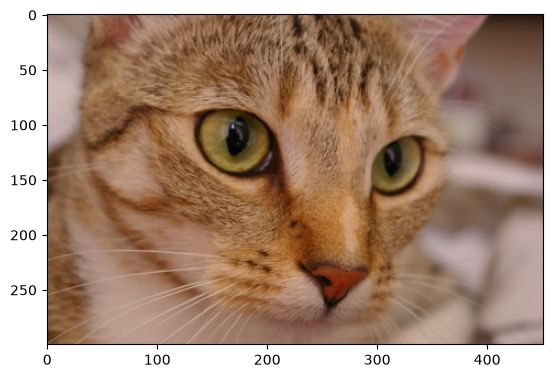

In [2]:
# ── Load image ────────────────────────────────────
my_image = data.chelsea()

plt.imshow(my_image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
height, width = my_image.shape[:2]
print(f"Image size: {width} x {height}")

# scaling factors
scale_x = 0.5
scale_y = 0.5

Image size: 451 x 300


In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
my_image_resized1 = cv2.resize(my_image, (0, 0), fx=scale_x, fy=scale_y)

# Resize the image using PIL's built-in method
my_image_resized2 = Image.fromarray(my_image).resize((int(width * scale_x), int(height * scale_y)))

In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
cv2.imwrite("task1_1_scaled.jpg", my_image_resized1)
print(f"Resized image size: {my_image_resized1.shape[1]} x {my_image_resized1.shape[0]}")

Resized image size: 226 x 150


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

Resized image size: 676 x 300


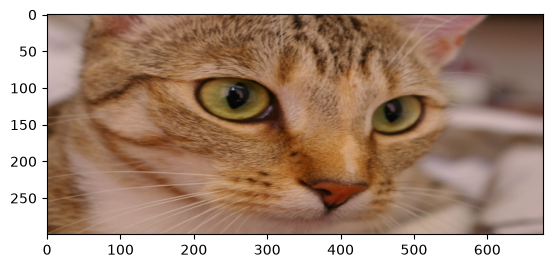

In [7]:
#non-uniform scaling stretching horizontally only 
scale_x = 2.0
scale_y = 1.0
my_image_resized3 = cv2.resize(my_image, (0, 0), fx=scale_x, fy=scale_y)
print(f"Resized image size: {my_image_resized3.shape[1]} x {my_image_resized3.shape[0]}")
plt.imshow(my_image_resized3)

Resized image size: 676 x 300


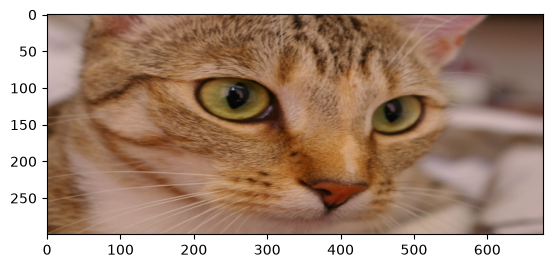

In [8]:
#Another try
scale_x = 1.5
scale_y = 1.0
my_image_resized3 = cv2.resize(my_image, (0, 0), fx=scale_x, fy=scale_y)
print(f"Resized image size: {my_image_resized3.shape[1]} x {my_image_resized3.shape[0]}")
plt.imshow(my_image_resized3)

Resized image size: 1804 x 300


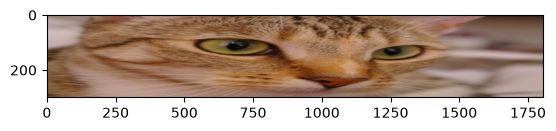

In [9]:
#One last value
scale_x = 4.0
scale_y = 1.0
my_image_resized3 = cv2.resize(my_image, (0, 0), fx=scale_x, fy=scale_y)
print(f"Resized image size: {my_image_resized3.shape[1]} x {my_image_resized3.shape[0]}")
plt.imshow(my_image_resized3)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

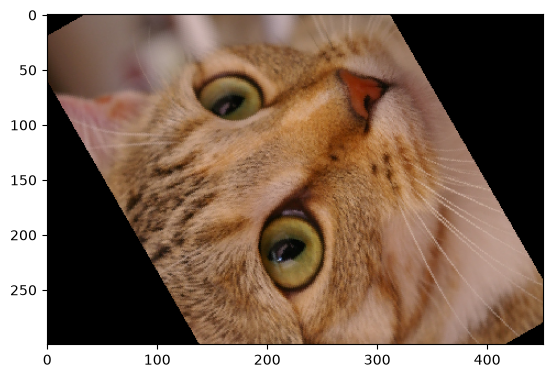

In [12]:
my_image_rotated = Image.fromarray(my_image).rotate(120)
my_image_rotated_np = np.array(my_image_rotated)

cv2.imwrite("task1_2_rotated.jpg", my_image_rotated_np)
plt.imshow(my_image_rotated_np)

### 3. Shear

In [16]:
# -- c. Get the image dimensions ────────────────────
width, height = my_image.shape[:2]
print(f"Image size: {width} x {height}")

Image size: 300 x 451


In [17]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0.0

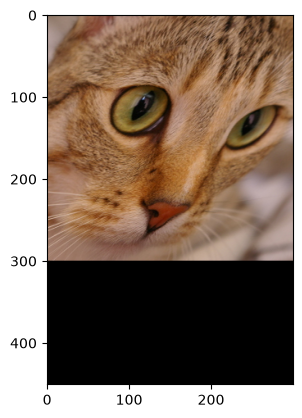

In [19]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
matrix = (1, shx, 0,
          shy, 1, 0)
my_image_pil = Image.fromarray(my_image)
sheared_image = my_image_pil.transform(
    (width, height),
    Image.AFFINE,
    matrix,
    resample=Image.BICUBIC
)
plt.imshow(sheared_image)

In [20]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
cv2.imwrite("task1_3_sheared.jpg", np.array(sheared_image))

True

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

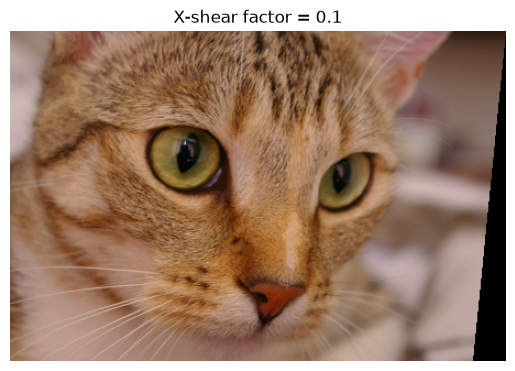

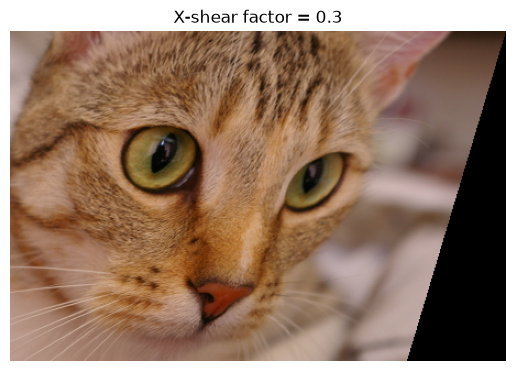

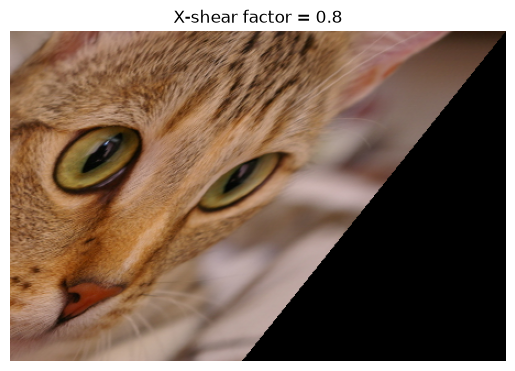

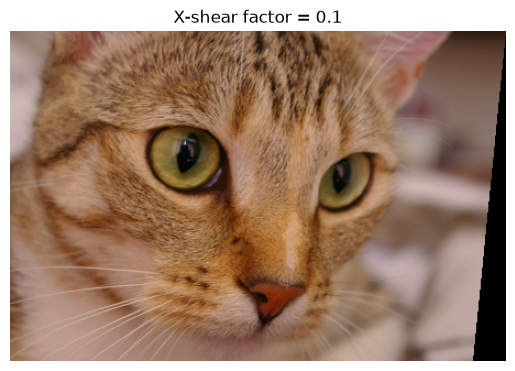

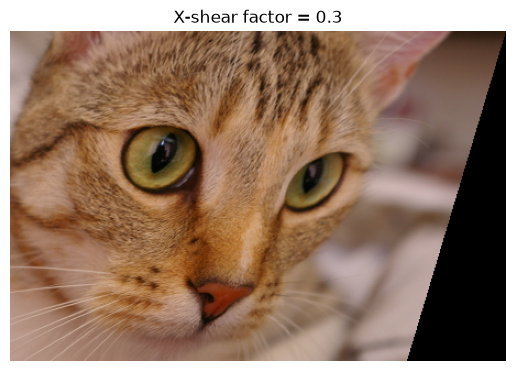

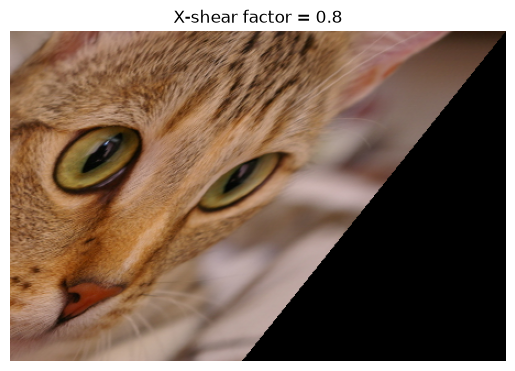

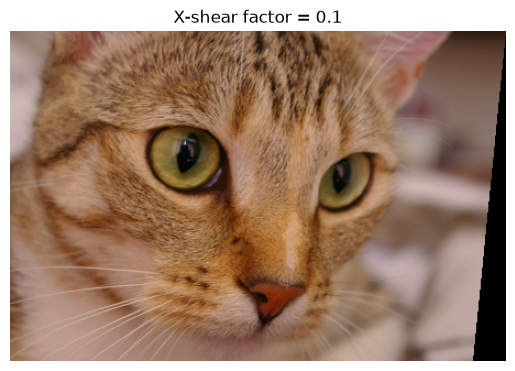

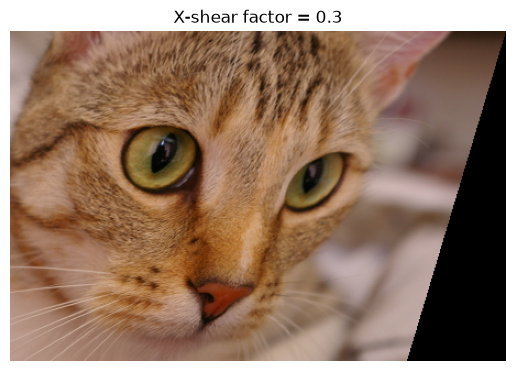

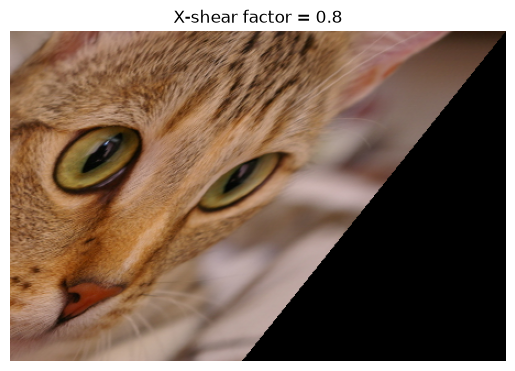

In [29]:

factors = [0.1, 0.3, 0.8]

for f in factors:
    def shear_x(image, shx):
        img_pil = Image.fromarray(image)
        matrix = (1, shx, 0,
                  0, 1, 0)
        return img_pil.transform(
            (image.shape[1], image.shape[0]),
            Image.AFFINE,
            matrix,
            resample=Image.BICUBIC
        )

    factors = [0.1, 0.3, 0.8]

    for f in factors:
        img_sheared = shear_x(my_image, f)
        plt.figure()
        plt.title(f"X-shear factor = {f}")
        plt.imshow(img_sheared)
        plt.axis("off")
   


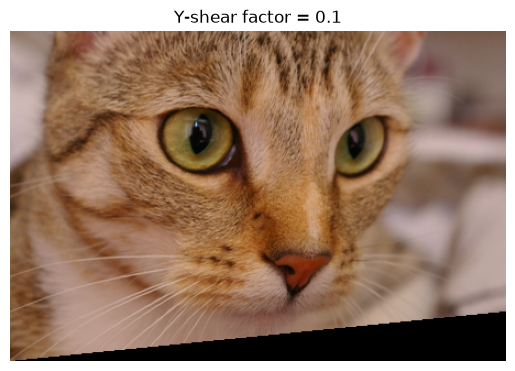

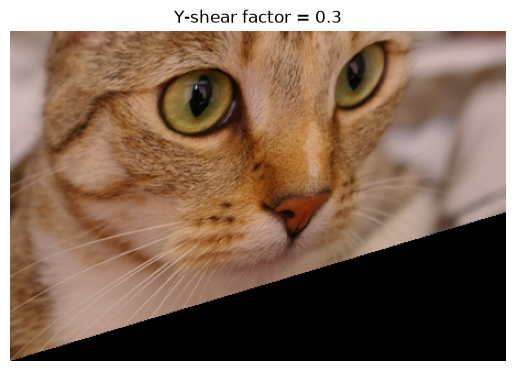

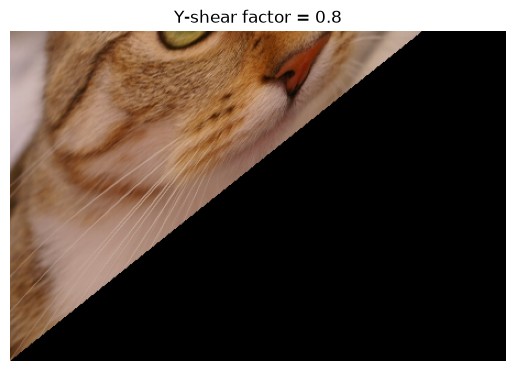

In [31]:
def shear_y(image, shy):
    image_pil = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    matrix = (1, 0, 0,
              shy, 1, 0)
    return image_pil.transform(
        image_pil.size,
        Image.AFFINE,
        matrix,
        resample=Image.BICUBIC
    )

for f in factors:
    img_sheared = shear_y(my_image, f)
    plt.figure()
    plt.title(f"Y‑shear factor = {f}")
    plt.imshow(img_sheared)
    plt.axis("off")

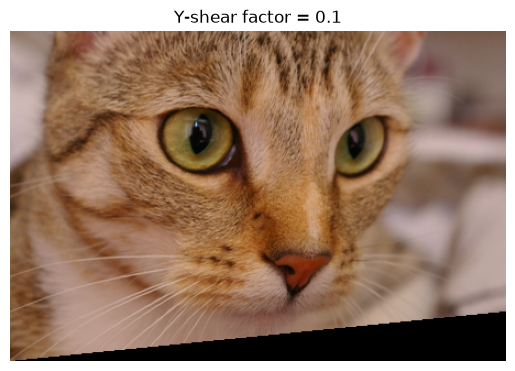

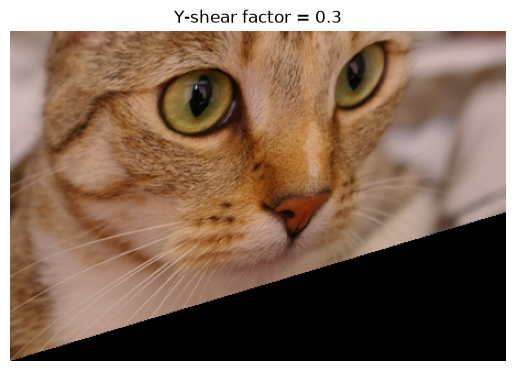

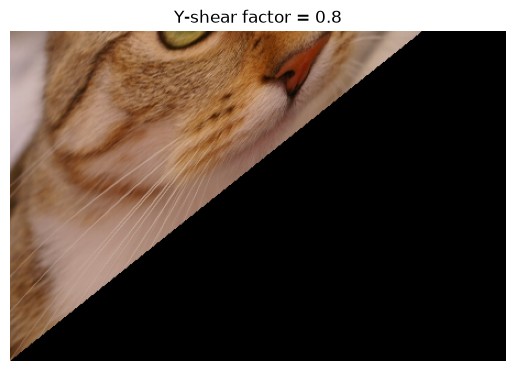

In [33]:
def shear_y(image, shy):
    image_pil = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    matrix = (1, 0, 0,
              shy, 1, 0)
    return image_pil.transform(
        image_pil.size,
        Image.AFFINE,
        matrix,
        resample=Image.BICUBIC
    )

for f in factors:
    img_sheared = shear_y(my_image, f)
    plt.figure()
    plt.title(f"Y‑shear factor = {f}")
    plt.imshow(img_sheared)
    plt.axis("off")

In [34]:
canvas_multiplier = 1 + abs(f)   # Updating the canvas multiplier to account for the shear factor
new_width = int(width * canvas_multiplier)
new_height = int(height * canvas_multiplier)


In [35]:
def shear_x_expand(image, shx):
    canvas_multiplier = 1 + abs(shx)
    new_width = int(width * canvas_multiplier)
    new_height = int(height * canvas_multiplier)

    matrix = (1, shx, 0,
              0, 1, 0)

    return image.transform((new_width, new_height), Image.AFFINE, matrix, resample=Image.BICUBIC)


(np.float64(-0.5), np.float64(299.5), np.float64(450.5), np.float64(-0.5))

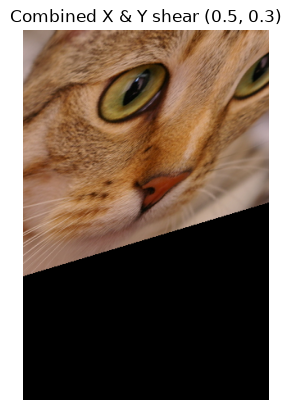

In [37]:
def shear_xy(image, shx, shy): #Combined X and Y shear
    matrix = (1, shx, 0,
              shy, 1, 0)
    return image.transform((width, height), Image.AFFINE, matrix, resample=Image.BICUBIC)

img_xy = Image.fromarray(my_image).transform(
    (width, height),
    Image.AFFINE,
    (1, 0.5, 0,
     0.3, 1, 0),
    resample=Image.BICUBIC
)

plt.imshow(img_xy)
plt.title("Combined X & Y shear (0.5, 0.3)")
plt.axis("off")


# Intensity Transformations
Negative · Log · Power Law (Gamma)

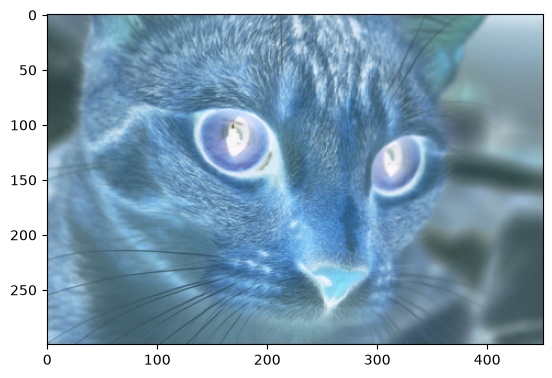

In [38]:

# ── 1. Negative intensity transformation ──────────────────────────────────── 
# Method 1: NumPy array manipulation

my_image_negative = 255 - my_image
plt.imshow(my_image_negative)

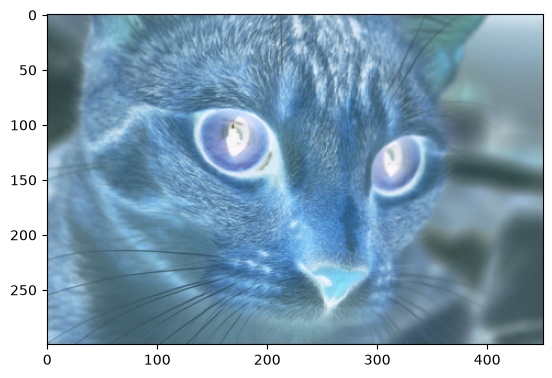

In [39]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
my_image_pil = Image.fromarray(my_image)
my_image_negative_pil = ImageOps.invert(my_image_pil)
plt.imshow(my_image_negative_pil)

(np.float64(-0.5), np.float64(450.5), np.float64(299.5), np.float64(-0.5))

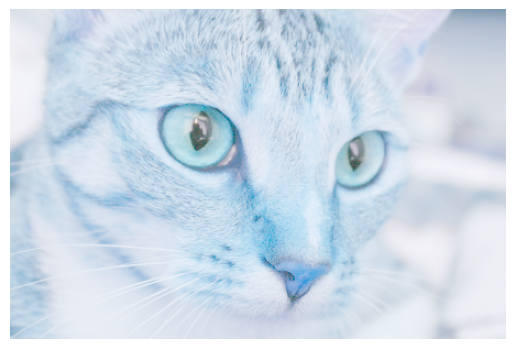

In [40]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
img_rgb = cv2.cvtColor(my_image, cv2.COLOR_BGR2RGB)
img_float = img_rgb.astype(np.float32)
c = 255 / np.log(1 + np.max(img_float))
# Apply the log transformation to each pixel
log_img = c * np.log(1 + img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

plt.imshow(log_img)
plt.axis("off")

(np.float64(-0.5), np.float64(450.5), np.float64(299.5), np.float64(-0.5))

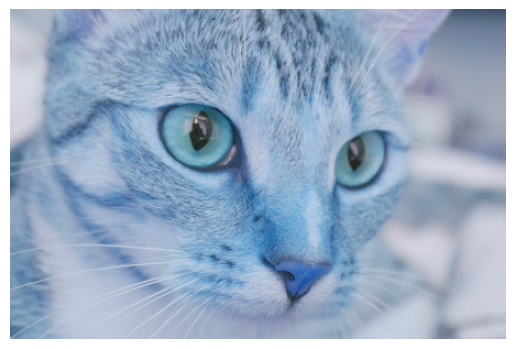

In [41]:

# ── 3. Power-law / Gamma correction ───────────────
img_rgb = cv2.cvtColor(my_image, cv2.COLOR_BGR2RGB)
img_norm = img_rgb / 255.0

# Choose gamma value
gamma = 0.5   # Try 0.3, 0.8, 1.5
gamma_img = np.power(img_norm, gamma)
gamma_img = (gamma_img * 255).astype(np.uint8)
plt.imshow(gamma_img)
plt.axis("off")